# Probit Regression

This GLM is a regression model used to model the probability of a binary outcome. It is used when the outcome is binary and the response variable is continuous. **The word Probit is a combination of words probability and unit**. Model main components are:

- **Random Component:** Binomial Distribution
- **Systematic Component:** Linear Predictor
- **Link Function:** Inverse of the cumulative normal distribution function

This GLM is useful when you have this assumption that the underlying process to generate the response variable is linear and normally distributed. It has a very similar approach to logistic regression, but it uses inver of the cumulative normal distribution function instead of the logistic function.

## Interpretability:

The change in the coefficients of the Probit models shows the change in the **z-score** of that random variable.

## Probit Regression Formula

$$
\begin{align}
link function:
\text{Probit}(p) = \Phi^{-1}(\text{p}) &= linear \ predictor \\
\end{align}
$$

- $\Phi^{-1}$ is the inverse of the standard normal cumulative distribution function also known as Probit function 

$$
\begin{align}
p &= \text{CDF}(z) = \Phi(z)
\end{align}
$$

- **probit** is the cumulative distribution function of the standard normal distribution
- $z$ is the linear predictor: $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_k x_k$
- $x_1, x_2, \ldots, x_k$ are the predictors
- $\beta_0, \beta_1, \beta_2, \ldots, \beta_k$ are the coefficients
- $p$ is the probability of the outcome being 1

## Assumptions

- The latent variables follow a normal distribution
- The target variable in binary (binomial distribution fits the data)
- Independence of observations
- Homoscedasticity

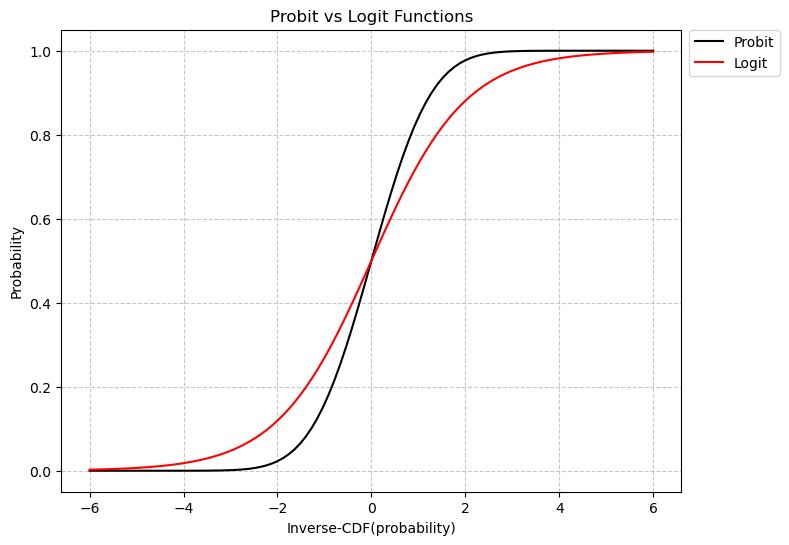

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

def probit(z):
	return norm.cdf(z)

def sigmoid(z):
	return 1 / (1 + np.exp(-z))

x = np.linspace(-6, 6, 100)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x, probit(x), color='black', label='Probit')
ax.plot(x, sigmoid(x), color='red', label='Logit')

ax.set(
	title="Probit vs Logit Functions",
	ylabel="Probability",
	xlabel="Inverse-CDF(probability)"
)
# put legend on top of the plot using bbox_to_anchor
ax.legend(loc='upper right', bbox_to_anchor=(1.17, 1.015))
ax.grid(True, linestyle='--', alpha=0.7)

We can see that probit regression decision making is similar to logistic regression but it reaches the boundaries much more quickly and represents more intensity of the decision making.

In [89]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import statsmodels.api as sm

# load the data
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X = X.filter(regex="mean|worst")

# split the data into training, testing, and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

# standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# create a logistic regression model
model = LogisticRegression(
    l1_ratio=0.9, solver="saga", max_iter=10000
)

# train the model on the training data
model.fit(X_train_scaled, y_train)

# make predictions on the testing data
y_pred = model.predict(X_test_scaled)

# calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9824561403508771


In [90]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X = X.filter(regex="mean|worst")

# split data into train, test, and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

# train probit regression model
model_pr = sm.Probit(y, X)
result = model_pr.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.061720
         Iterations 12
                          Probit Regression Results                           
Dep. Variable:                 target   No. Observations:                  569
Model:                         Probit   Df Residuals:                      549
Method:                           MLE   Df Model:                           19
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                  0.9065
Time:                        20:35:01   Log-Likelihood:                -35.119
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                3.445e-132
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
mean radius                 4.1386      4.403      0.940      0.347      -4.492  

In [91]:
y_pred = (result.predict(X_test) > 0.5).astype(int)
print(f"Accuracy of the Probit Model: {accuracy_score(y_test, y_pred)}")

Accuracy of the Probit Model: 0.9912280701754386


In [92]:
import pandas as pd

coefficients = pd.DataFrame(result.params, columns=["probit_model"])
coefficients['logistic_regression_model'] = model.coef_.reshape(-1, 1)
coefficients

,probit_model,logistic_regression_model
mean radius,4.138623,0.000000
mean texture,-0.247250,-0.429640
mean perimeter,-0.259132,0.000000
mean area,-0.016091,0.000000
mean smoothness,-57.543983,-0.623450
mean compactness,48.691123,0.589291
mean concavity,6.800130,0.000000
mean concave points,-85.343752,-1.698072
mean symmetry,-6.560628,-0.064480
mean fractal dimension,10.799376,0.000000
